## **Portafolio de tecnología**

In [64]:
%pip install matplotlib.pyploy

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyploy (from versions: none)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyploy


In [67]:
import yfinance as yf
import openpyxl
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt

In [44]:
empresas = pd.read_excel("../config/SP500_yfinance.xlsx")
empresas.head(1000)

,Ticket,Nombre,Sector
0,APP,AppLovin,Communication Services
1,CHTR,Charter Communications,Communication Services
2,CMCSA,Comcast,Communication Services
3,DIS,Walt Disney Company (The),Communication Services
4,ECHO,EchoStar,Communication Services
...,...,...,...
498,SO,Southern Company,Utilities
499,SRE,Sempra,Utilities
500,VST,Vistra Corp.,Utilities
501,WEC,WEC Energy Group,Utilities


In [45]:
sectores = empresas.groupby("Sector")["Ticket"].apply(list).to_dict()
acciones = empresas["Ticket"].to_list()
precios = yf.download(acciones, start = "2026-01-01", end = str (date.today()))["Close"]

[***                    6%                       ]  28 of 503 completed$BRK.B: possibly delisted; no timezone found
[**********************87%*****************      ]  437 of 503 completed$BF.B: possibly delisted; no price data found  (1d 2026-01-01 -> 2026-08-27)
[*********************100%***********************]  502 of 503 completed

2 Failed downloads:
['BRK.B']: possibly delisted; no timezone found
['BF.B']: possibly delisted; no price data found  (1d 2026-01-01 -> 2026-08-27)


In [48]:
def datos_sector (ticket_sector,df_precios):
    tickets = [t for t in ticket_sector if t in df_precios.columns]
    return df_precios[tickets]

In [57]:
def rendimientos(df_precios):
    rendimientos = df_precios.pct_change().dropna()
    return rendimientos

In [55]:
precios_tecnologia= datos_sector(sectores["Information Technology"],precios).round(2)
precios_tecnologia

Ticker,AAPL,ACN,ADBE,ADI,ADSK,AKAM,AMAT,AMD,ANET,APH,...,TDY,TEL,TER,TRMB,TXN,TYL,VRSN,WDAY,WDC,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,270.27,254.70,333.30,272.14,286.73,85.10,267.92,223.47,133.60,139.22,...,518.77,230.71,207.39,78.33,174.58,435.83,238.30,205.79,187.56,248.30
2026-01-05,266.53,258.65,331.56,275.67,288.66,85.91,283.31,221.08,137.19,139.39,...,524.09,228.91,219.33,79.27,174.24,441.10,237.04,208.90,187.74,252.64
2026-01-06,261.65,270.36,335.99,291.23,293.17,88.74,294.96,214.35,132.58,140.89,...,532.73,228.82,228.66,81.55,188.92,443.66,243.92,210.30,219.22,257.61
2026-01-07,259.62,268.45,338.10,291.18,293.79,88.18,291.16,210.02,130.08,138.43,...,531.48,227.12,222.30,80.18,182.64,448.23,241.52,211.14,199.73,246.96
2026-01-08,258.34,276.13,339.04,297.41,276.58,85.71,280.64,204.68,123.72,135.78,...,548.91,225.58,216.14,79.51,185.33,453.40,244.84,209.79,187.54,254.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-20,311.30,181.35,272.22,370.24,251.02,110.09,496.21,469.46,183.75,153.11,...,633.95,199.76,383.15,59.68,265.60,348.14,276.90,197.32,469.05,360.52
2026-08-21,309.35,185.28,275.30,373.09,253.83,110.42,492.32,473.25,188.65,157.01,...,636.15,203.52,375.74,60.25,264.36,350.73,281.80,200.01,459.44,368.51
2026-08-24,310.34,186.53,276.27,371.17,254.42,105.66,484.19,456.75,188.15,155.55,...,625.21,202.41,364.90,60.67,258.94,355.79,290.79,199.15,435.38,363.30


In [58]:
rendimientos_tecnologia = rendimientos(precios_tecnologia).round(4)
rendimientos_tecnologia

Ticker,AAPL,ACN,ADBE,ADI,ADSK,AKAM,AMAT,AMD,ANET,APH,...,TDY,TEL,TER,TRMB,TXN,TYL,VRSN,WDAY,WDC,ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-05,-0.0138,0.0155,-0.0052,0.0130,0.0067,0.0095,0.0574,-0.0107,0.0269,0.0012,...,0.0103,-0.0078,0.0576,0.0120,-0.0019,0.0121,-0.0053,0.0151,0.0010,0.0175
2026-01-06,-0.0183,0.0453,0.0134,0.0564,0.0156,0.0329,0.0411,-0.0304,-0.0336,0.0108,...,0.0165,-0.0004,0.0425,0.0288,0.0843,0.0058,0.0290,0.0067,0.1677,0.0197
2026-01-07,-0.0078,-0.0071,0.0063,-0.0002,0.0021,-0.0063,-0.0129,-0.0202,-0.0189,-0.0175,...,-0.0023,-0.0074,-0.0278,-0.0168,-0.0332,0.0103,-0.0098,0.0040,-0.0889,-0.0413
2026-01-08,-0.0049,0.0286,0.0028,0.0214,-0.0586,-0.0280,-0.0361,-0.0254,-0.0489,-0.0191,...,0.0328,-0.0068,-0.0277,-0.0084,0.0147,0.0115,0.0137,-0.0064,-0.0610,0.0311
2026-01-09,0.0013,-0.0041,-0.0150,0.0059,-0.0020,0.0281,0.0694,-0.0074,-0.0067,0.0286,...,0.0002,0.0156,0.0044,0.0138,0.0099,-0.0111,0.0074,-0.0124,0.0681,0.0190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-20,-0.0175,-0.0099,-0.0009,-0.0081,-0.0011,-0.0244,0.0012,0.0065,-0.0145,-0.0188,...,-0.0226,-0.0149,0.0092,0.0073,-0.0069,0.0036,0.0142,-0.0055,0.0151,0.0166
2026-08-21,-0.0063,0.0217,0.0113,0.0077,0.0112,0.0030,-0.0078,0.0081,0.0267,0.0255,...,0.0035,0.0188,-0.0193,0.0096,-0.0047,0.0074,0.0177,0.0136,-0.0205,0.0222
2026-08-24,0.0032,0.0067,0.0035,-0.0051,0.0023,-0.0431,-0.0165,-0.0349,-0.0027,-0.0093,...,-0.0172,-0.0055,-0.0288,0.0070,-0.0205,0.0144,0.0319,-0.0043,-0.0524,-0.0141


In [85]:
def graficar_precios(df_precios, titulo):
    ax = df_precios.plot(
        figsize = (14,7),
        linewidth = 1.5
    )
    ax.set_title(titulo)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio de cierre")
    ax.grid(True, alpha =0.3)
    ax.legend(title="Ticket",bbox_to_anchor=(1.02,0.5),loc="upper left")

    plt.tight_layout()
    plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13224\4178795125.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


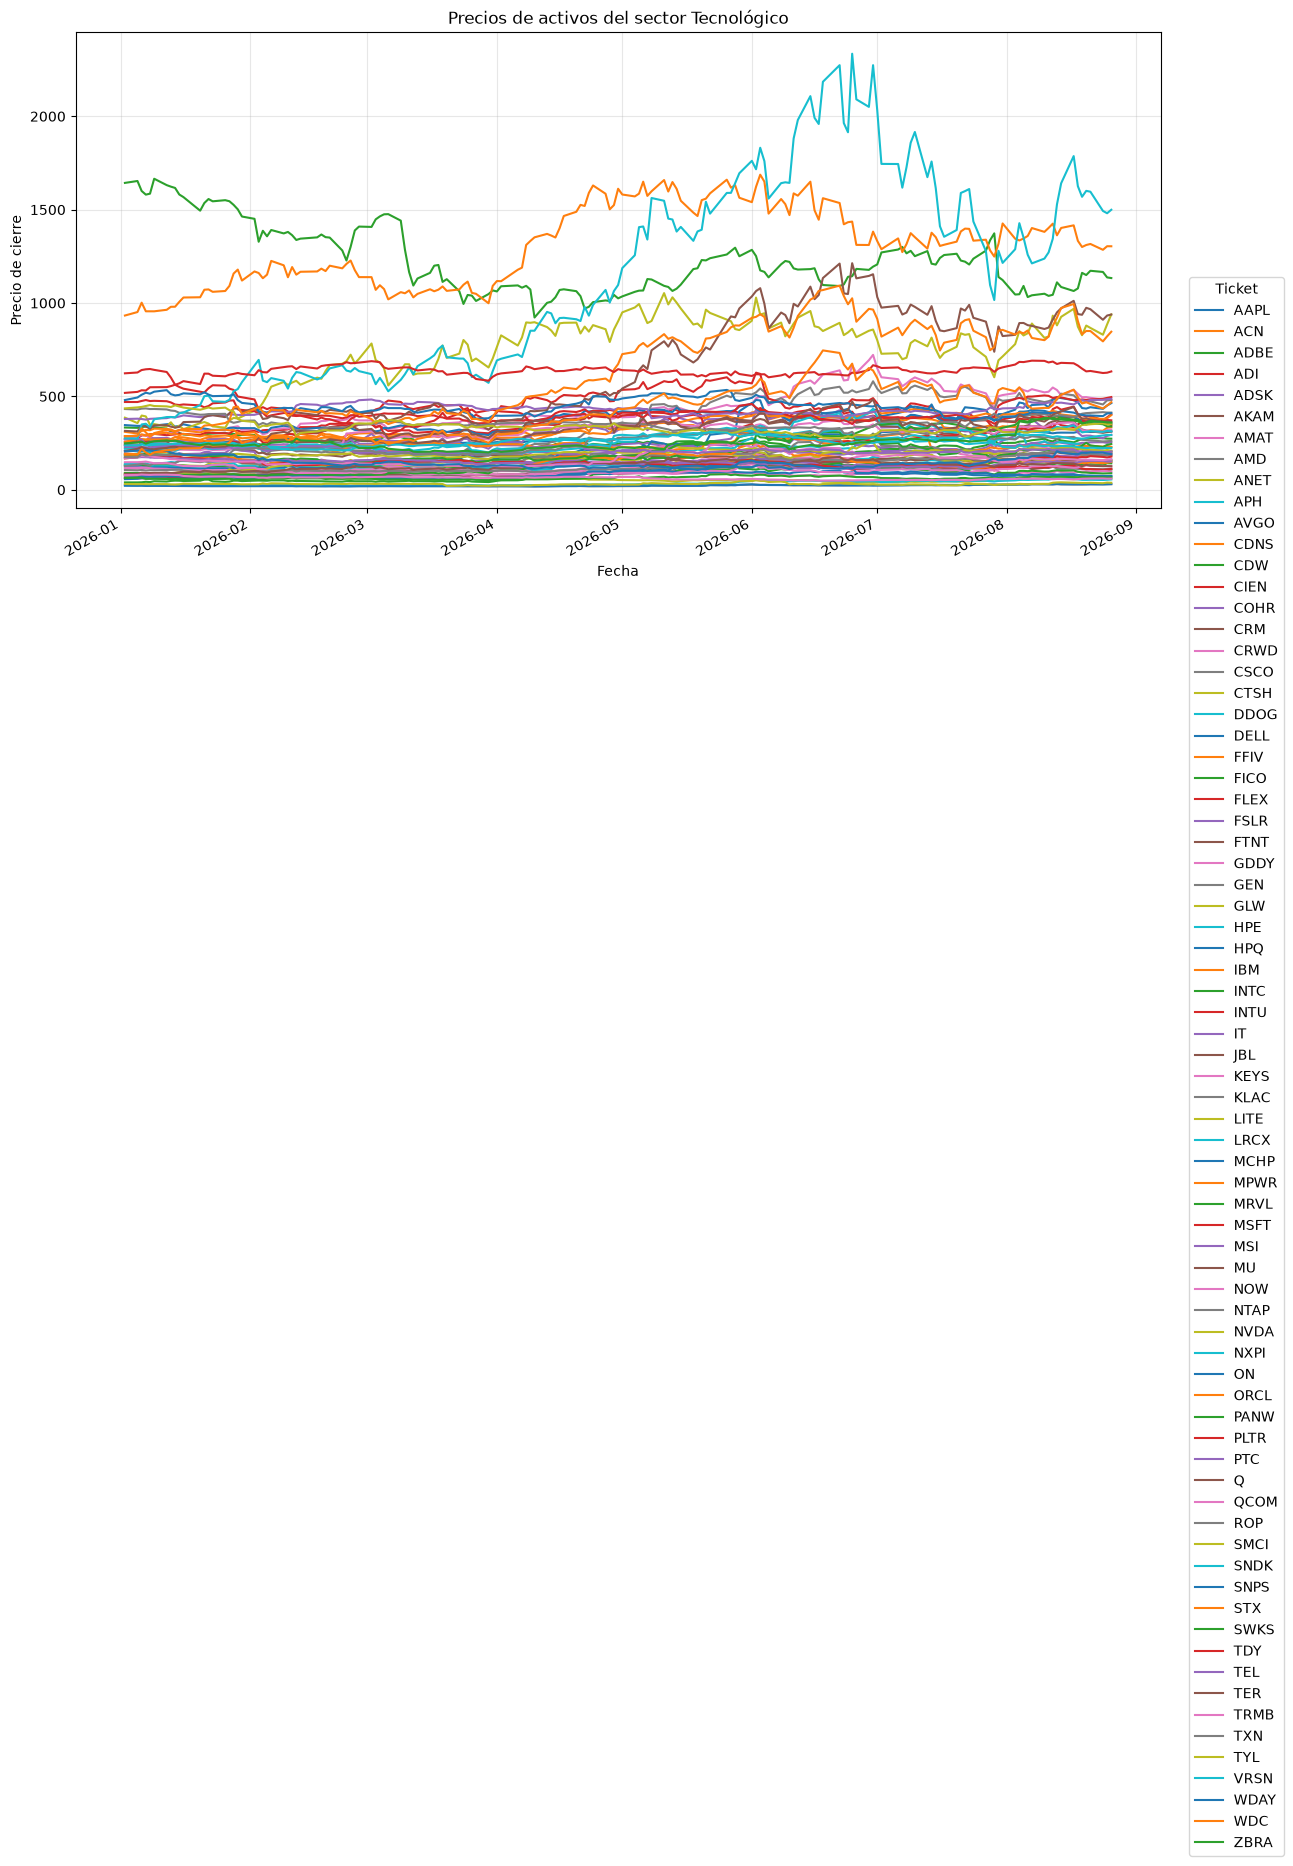

In [86]:
graficar_precios(precios_tecnologia,"Precios de activos del sector Tecnológico")